[00] lin_uni (d=1): 1.87*x1 + 2.01
[01] lin_bi (d=2): 1.56*x1 + 1.59*x2 - 2.91
[02] poly2_uni (d=1): 2.48*x1**2 + 1.92*x1 - 0.68
[03] poly2_bi (d=2): 0.55*x1**2 + 2.45*x1*x2 + 1.65*x1 + 2.95*x2**2 + 0.8*x2 + 0.86
[04] log_poly2_sign2 (d=1): -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
[05] sqrt_poly2_sign2 (d=1): 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
[06] rat_linlin_uni_pole_train (d=1): (0.53 - 2.94*x1)/(2.32*x1 + 1.8)
[07] rat_linlin_bi_pole_train (d=2): (1.0*x1 + 2.48*x2 - 1.36)/(2.26*x1 - 0.91*x2 + 1.94)
[08] rat_poly2poly2_uni_one_pole_train (d=1): (-2.84*x1**2 - 1.84*x1 + 2.33)/(-1.84*x1**2 + 2.98*x1 + 2.16)
[09] rat_poly2poly2_uni_two_poles_train (d=1): (-0.55*x1**2 + 1.3*x1 - 1.97)/(-1.88*x1**2 + 2.9*x1 + 1.1)


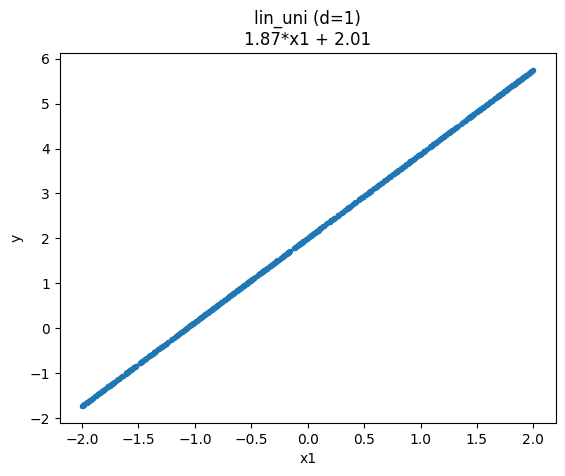

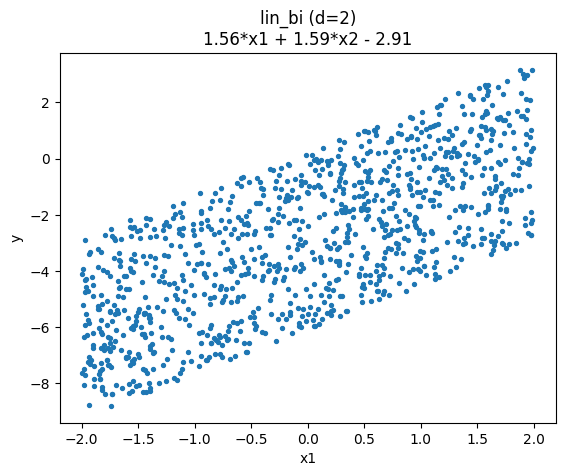

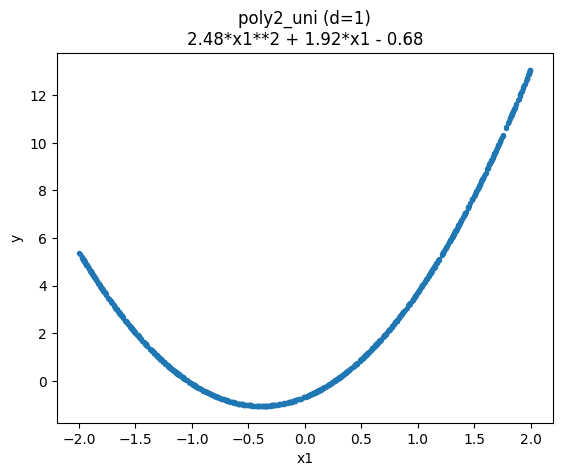

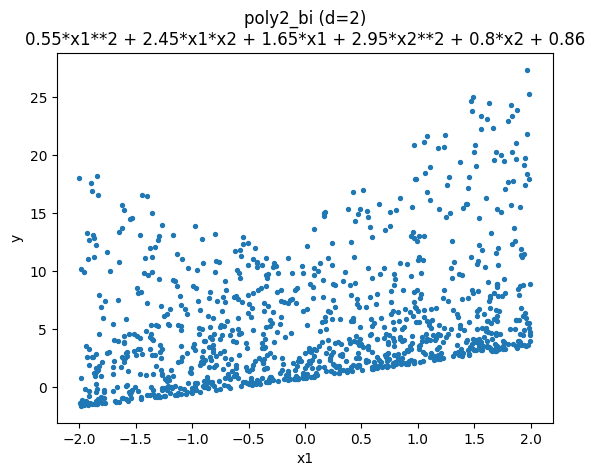

<lambdifygenerated-14>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-15>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-16>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-17>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-18>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-19>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-20>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerated-21>:2: RuntimeWarning: invalid value encountered in log
  return -2.05*log(1.56*x1**2 - 0.55*x1 - 2.15)
<lambdifygenerat

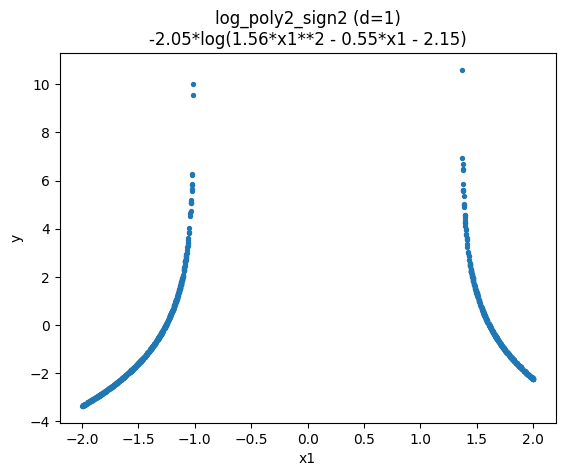

<lambdifygenerated-47>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-48>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-49>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-50>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-51>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-52>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-53>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdifygenerated-54>:2: RuntimeWarning: invalid value encountered in sqrt
  return 2.31*sqrt(2.52*x1**2 - 1.52*x1 - 2.24)
<lambdif

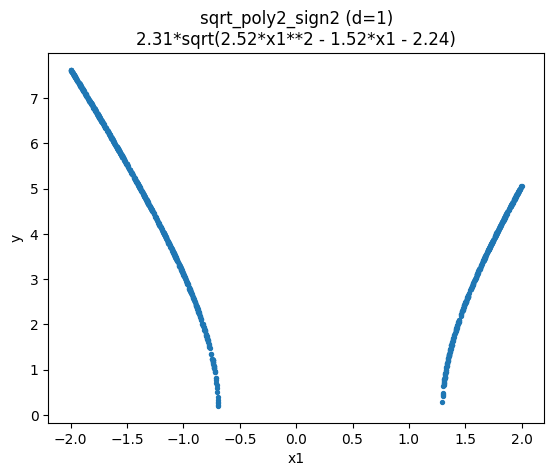

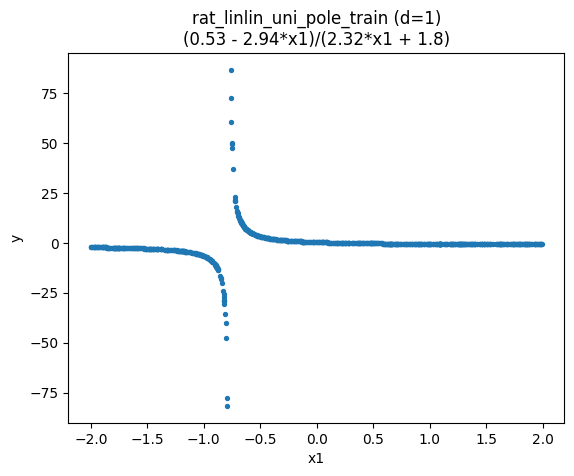

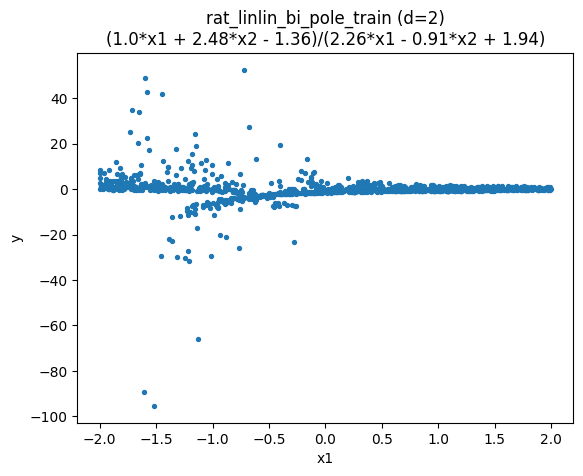

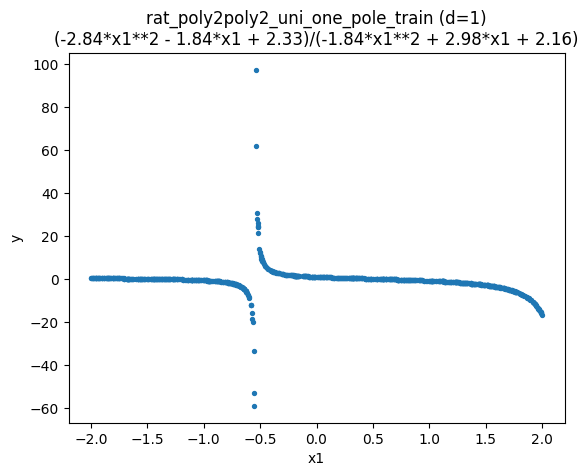

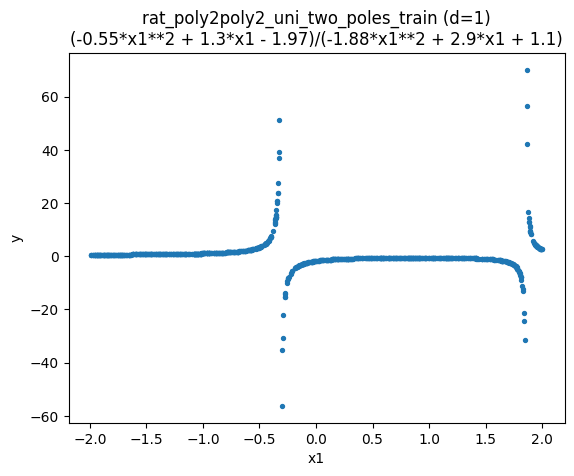


Saved: data/sr_benchmark.h5


In [1]:
from __future__ import annotations

from typing import List, Tuple, Callable, Optional

from config.benchmark_config import DataCFG

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp


def _signed_uniform(rng: np.random.RandomState, min_abs: float, max_abs: float, decimals: int) -> float:
    mag = rng.uniform(min_abs, max_abs)
    sgn = -1.0 if rng.rand() < 0.5 else 1.0
    return float(np.round(sgn * mag, decimals))


def _coef(rng: np.random.RandomState, cfg: DataCFG) -> float:
    return _signed_uniform(rng, cfg.coeff_min_abs, cfg.coeff_max_abs, cfg.coeff_decimals)


def _inner_const(rng: np.random.RandomState, cfg: DataCFG) -> float:
    return _signed_uniform(rng, cfg.inner_const_min_abs, cfg.inner_const_max_abs, cfg.inner_const_decimals)


def _float2(v: float, dec: int) -> sp.Float:
    return sp.Float(f"{v:.{dec}f}")


def _sample_X_uniform(rng: np.random.RandomState, n: int, d: int, low: float, high: float) -> np.ndarray:
    return rng.uniform(low, high, size=(n, d)).astype(np.float64, copy=False)


def _sample_X_extrap(rng: np.random.RandomState, n: int, d: int, cfg: DataCFG) -> np.ndarray:
    u = rng.rand(n, d)
    X = np.empty((n, d), dtype=np.float64)
    mask = u < 0.5
    X[mask] = rng.uniform(cfg.extrap_a_low, cfg.extrap_a_high, size=mask.sum())
    X[~mask] = rng.uniform(cfg.extrap_b_low, cfg.extrap_b_high, size=(~mask).sum())
    return X


def _eval_expr_numpy(expr: sp.Expr, xs: List[sp.Symbol], X: np.ndarray) -> np.ndarray:
    f = sp.lambdify(xs, expr, modules=["numpy"])
    y = f(*[X[:, i] for i in range(X.shape[1])])
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return y


def _accept_mask(y: np.ndarray, y_abs_max: float) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return np.isfinite(y) & (np.abs(y) <= y_abs_max)


def _rand_poly2_expanded_two_roots_in_train(
    rng: np.random.RandomState,
    cfg: DataCFG,
    x1: sp.Symbol,
    *,
    require_A_pos: bool,
    max_root_span: Optional[float] = None,
) -> sp.Expr:
    dec = cfg.coeff_decimals
    L = cfg.train_low
    H = cfg.train_high

    for _ in range(cfg.max_rounds):
        A = _coef(rng, cfg)
        B = _coef(rng, cfg)
        C = _coef(rng, cfg)

        if require_A_pos and A <= 0.0:
            continue

        D = B * B - 4.0 * A * C
        if D <= 0.0:
            continue

        sD = float(np.sqrt(D))
        r1 = (-B - sD) / (2.0 * A)
        r2 = (-B + sD) / (2.0 * A)
        r_lo, r_hi = (r1, r2) if r1 <= r2 else (r2, r1)

        if not (L <= r_lo and r_hi <= H):
            continue

        if max_root_span is not None and (r_hi - r_lo) > max_root_span:
            continue

        p = _float2(A, dec) * x1**2 + _float2(B, dec) * x1 + _float2(C, dec)
        return sp.expand(p)

    raise RuntimeError("Could not sample expanded quadratic with two roots in the training domain.")


def _rand_poly2_uni_two_sign_changes_in_train(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals

    r1 = float(np.round(rng.uniform(cfg.train_low, cfg.train_high), dec))
    r2 = float(np.round(rng.uniform(cfg.train_low, cfg.train_high), dec))
    if r2 < r1:
        r1, r2 = r2, r1

    a = _coef(rng, cfg)
    p = _float2(a, dec) * (x1 - _float2(r1, dec)) * (x1 - _float2(r2, dec))
    return sp.expand(p)


def _sample_and_eval_until_n(
    *,
    rng: np.random.RandomState,
    cfg: DataCFG,
    expr: sp.Expr,
    xs: List[sp.Symbol],
    n_target: int,
    d: int,
    sampler: Callable[[int, int], np.ndarray],
    y_abs_max: float = 100,
) -> Tuple[np.ndarray, np.ndarray]:
    X_acc: List[np.ndarray] = []
    y_acc: List[np.ndarray] = []
    n_ok = 0

    for _ in range(cfg.max_rounds):
        n_need = n_target - n_ok
        if n_need <= 0:
            break

        n_batch = cfg.batch_size if n_need > cfg.batch_size else n_need
        Xb = sampler(n_batch, d)
        yb = _eval_expr_numpy(expr, xs, Xb)

        m = _accept_mask(yb, y_abs_max)

        if np.any(m):
            X_acc.append(Xb[m])
            y_acc.append(yb[m])
            n_ok += int(np.sum(m))

    if n_ok < n_target:
        raise RuntimeError(f"Not enough accepted samples for expr={expr}. Collected {n_ok}/{n_target}.")

    X = np.vstack(X_acc)[:n_target]
    y = np.concatenate(y_acc)[:n_target]
    return X, y


def _grid_minabs_2d(expr: sp.Expr, xs: List[sp.Symbol], low: float, high: float, n_grid: int) -> float:
    g = sp.lambdify(xs, expr, modules=["numpy"])
    grid = np.linspace(low, high, n_grid, dtype=np.float64)
    X0, X1 = np.meshgrid(grid, grid, indexing="xy")
    v = np.asarray(g(X0, X1), dtype=np.float64)
    return float(np.min(np.abs(v)))


def _pole_presence(minabs: float, eps: float) -> bool:
    return minabs < eps


def _rand_linear_2d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol, x2: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    return _float2(_coef(rng, cfg), dec) * x1 + _float2(_coef(rng, cfg), dec) * x2 + _float2(_coef(rng, cfg), dec)


def _rand_poly2_2d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol, x2: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    return (
        _float2(_coef(rng, cfg), dec) * x1**2
        + _float2(_coef(rng, cfg), dec) * x1 * x2
        + _float2(_coef(rng, cfg), dec) * x2**2
        + _float2(_coef(rng, cfg), dec) * x1
        + _float2(_coef(rng, cfg), dec) * x2
        + _float2(_coef(rng, cfg), dec)
    )


def _rand_linear_1d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    return _float2(_coef(rng, cfg), dec) * x1 + _float2(_coef(rng, cfg), dec)


def _rand_poly2_1d(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    return (
        _float2(_coef(rng, cfg), dec) * x1**2
        + _float2(_coef(rng, cfg), dec) * x1
        + _float2(_coef(rng, cfg), dec)
    )


def _rand_lin_1d_one_pole_in_train_expanded(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    L, H = cfg.train_low, cfg.train_high

    for _ in range(cfg.max_rational_trials):
        a = _coef(rng, cfg)
        b = _coef(rng, cfg)
        if abs(a) < 1e-12:
            continue
        r = -b / a
        if L <= r <= H:
            return sp.expand(_float2(a, dec) * x1 + _float2(b, dec))

    raise RuntimeError("Could not sample 1D linear denominator with a pole in the training domain.")


def _rand_poly2_1d_one_pole_in_train_expanded(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    L, H = cfg.train_low, cfg.train_high

    for _ in range(cfg.max_rational_trials):
        a = _coef(rng, cfg)
        b = _coef(rng, cfg)
        c = _coef(rng, cfg)

        if abs(a) < 1e-12:
            continue

        D = b * b - 4.0 * a * c
        if D <= 0.0:
            continue

        sD = float(np.sqrt(D))
        r1 = (-b - sD) / (2.0 * a)
        r2 = (-b + sD) / (2.0 * a)

        in1 = (L <= r1 <= H)
        in2 = (L <= r2 <= H)

        if in1 ^ in2:
            q = _float2(a, dec) * x1**2 + _float2(b, dec) * x1 + _float2(c, dec)
            return sp.expand(q)

    raise RuntimeError("Could not sample 1D poly2 denominator with exactly one pole in the training domain.")


def _rand_poly2_1d_two_poles_in_train_expanded(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    L, H = cfg.train_low, cfg.train_high

    for _ in range(cfg.max_rational_trials):
        a = _coef(rng, cfg)
        b = _coef(rng, cfg)
        c = _coef(rng, cfg)

        if abs(a) < 1e-12:
            continue

        D = b * b - 4.0 * a * c
        if D <= 0.0:
            continue

        sD = float(np.sqrt(D))
        r1 = (-b - sD) / (2.0 * a)
        r2 = (-b + sD) / (2.0 * a)
        r_lo, r_hi = (r1, r2) if r1 <= r2 else (r2, r1)

        if L <= r_lo and r_hi <= H:
            q = _float2(a, dec) * x1**2 + _float2(b, dec) * x1 + _float2(c, dec)
            return sp.expand(q)

    raise RuntimeError("Could not sample 1D poly2 denominator with two poles in training domain.")


def _rand_parabola_poly2_2d_in_train_expanded(rng: np.random.RandomState, cfg: DataCFG, x1: sp.Symbol, x2: sp.Symbol) -> sp.Expr:
    dec = cfg.coeff_decimals
    return _rand_poly2_2d(rng, cfg, x1, x2)


def _make_rat_linlin_uni_pole_in_train(rng: np.random.RandomState, cfg: DataCFG) -> sp.Expr:
    x1 = sp.Symbol("x1", real=True)
    p = _rand_linear_1d(rng, cfg, x1)
    q = _rand_linear_1d(rng, cfg, x1)
    return sp.simplify(p / q)


def _make_rat_poly2poly2_uni_one_pole_in_train(rng: np.random.RandomState, cfg: DataCFG) -> sp.Expr:
    x1 = sp.Symbol("x1", real=True)
    p = _rand_poly2_1d(rng, cfg, x1)
    q = _rand_poly2_1d_one_pole_in_train_expanded(rng, cfg, x1)
    return sp.simplify(p / q)


def _make_rat_poly2poly2_uni_two_poles_in_train(rng: np.random.RandomState, cfg: DataCFG) -> sp.Expr:
    x1 = sp.Symbol("x1", real=True)
    p = _rand_poly2_1d(rng, cfg, x1)
    q = _rand_poly2_1d_two_poles_in_train_expanded(rng, cfg, x1)
    return sp.simplify(p / q)


def _make_rat_linlin_bi_pole_in_train(rng: np.random.RandomState, cfg: DataCFG) -> sp.Expr:
    x1, x2 = sp.symbols("x1 x2", real=True)
    p = _rand_linear_2d(rng, cfg, x1, x2)
    q = _rand_linear_2d(rng, cfg, x1, x2)
    return sp.simplify(p / q)


def _make_expressions(rng: np.random.RandomState, cfg: DataCFG) -> List[Tuple[str, int, sp.Expr]]:
    x1, x2 = sp.symbols("x1 x2", real=True)
    dec = cfg.coeff_decimals

    out: List[Tuple[str, int, sp.Expr]] = []

    out.append(("lin_uni", 1, _float2(_coef(rng, cfg), dec) * x1 + _float2(_coef(rng, cfg), dec)))
    out.append(
        (
            "lin_bi",
            2,
            _float2(_coef(rng, cfg), dec) * x1
            + _float2(_coef(rng, cfg), dec) * x2
            + _float2(_coef(rng, cfg), dec),
        )
    )
    out.append(
        (
            "poly2_uni",
            1,
            _float2(_coef(rng, cfg), dec) * x1**2
            + _float2(_coef(rng, cfg), dec) * x1
            + _float2(_coef(rng, cfg), dec),
        )
    )
    out.append(
        (
            "poly2_bi",
            2,
            _float2(_coef(rng, cfg), dec) * x1**2
            + _float2(_coef(rng, cfg), dec) * x1 * x2
            + _float2(_coef(rng, cfg), dec) * x2**2
            + _float2(_coef(rng, cfg), dec) * x1
            + _float2(_coef(rng, cfg), dec) * x2
            + _float2(_coef(rng, cfg), dec),
        )
    )

    max_span = 0.7 * (cfg.train_high - cfg.train_low)

    p_log = _rand_poly2_expanded_two_roots_in_train(rng, cfg, x1, require_A_pos=True, max_root_span=max_span)
    out.append(("log_poly2_sign2", 1, _float2(_coef(rng, cfg), dec) * sp.log(p_log)))

    p_sqrt = _rand_poly2_expanded_two_roots_in_train(rng, cfg, x1, require_A_pos=True, max_root_span=max_span)
    out.append(("sqrt_poly2_sign2", 1, _float2(_coef(rng, cfg), dec) * sp.sqrt(p_sqrt)))

    out.append(("rat_linlin_uni_pole_train", 1, _make_rat_linlin_uni_pole_in_train(rng, cfg)))
    out.append(("rat_linlin_bi_pole_train", 2, _make_rat_linlin_bi_pole_in_train(rng, cfg)))
    out.append(("rat_poly2poly2_uni_one_pole_train", 1, _make_rat_poly2poly2_uni_one_pole_in_train(rng, cfg)))
    out.append(("rat_poly2poly2_uni_two_poles_train", 1, _make_rat_poly2poly2_uni_two_poles_in_train(rng, cfg)))

    return out


def _print_exprs(exprs: List[Tuple[str, int, sp.Expr]]) -> None:
    for i, (name, d, expr) in enumerate(exprs):
        print(f"[{i:02d}] {name} (d={d}): {expr}")


def main() -> None:
    cfg = DataCFG()
    rng = np.random.RandomState(cfg.seed)

    x1, x2 = sp.symbols("x1 x2", real=True)
    sym_by_d = {1: [x1], 2: [x1, x2]}

    exprs = _make_expressions(rng, cfg)
    _print_exprs(exprs)

    with h5py.File(cfg.h5_path, "w") as f:
        dt = h5py.string_dtype(encoding="utf-8")

        for idx, (name, d, expr) in enumerate(exprs):
            g = f.create_group(f"expr_{idx:03d}_{name}")
            g.create_dataset("sympy_str", data=sp.sstr(expr), dtype=dt)

            xs = sym_by_d[d]

            train_sampler = lambda n, dd: _sample_X_uniform(rng, n, dd, cfg.train_low, cfg.train_high)
            interp_sampler = lambda n, dd: _sample_X_uniform(rng, n, dd, cfg.train_low, cfg.train_high)
            extrap_sampler = lambda n, dd: _sample_X_extrap(rng, n, dd, cfg)

            Xtr, ytr = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_train, d=d, sampler=train_sampler
            )
            Xte_i, yte_i = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_test_interp, d=d, sampler=interp_sampler
            )
            Xte_e, yte_e = _sample_and_eval_until_n(
                rng=rng, cfg=cfg, expr=expr, xs=xs, n_target=cfg.n_test_extrap, d=d, sampler=extrap_sampler
            )

            plt.figure()
            plt.scatter(Xtr[:, 0], ytr, s=8)
            plt.xlabel("x1")
            plt.ylabel("y")
            plt.title(f"{name} (d={d})\n{expr}")
            plt.show()

            g_tr = g.create_group("train")
            g_tr.create_dataset("X", data=Xtr)
            g_tr.create_dataset("y", data=ytr)

            g_ti = g.create_group("test_interp")
            g_ti.create_dataset("X", data=Xte_i)
            g_ti.create_dataset("y", data=yte_i)

            g_te = g.create_group("test_extrap")
            g_te.create_dataset("X", data=Xte_e)
            g_te.create_dataset("y", data=yte_e)

    print(f"\nSaved: {cfg.h5_path}")


if __name__ == "__main__":
    main()
